## Step 1 – Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
df_raw = pd.read_csv('Telco-Customer-Churn.csv')

print('Shape:', df_raw.shape)
print('\nFirst 5 rows:')
display(df_raw.head())
print('\nMissing values:')
print(df_raw.isnull().sum())

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Step 2 – Class Distribution (Original Data)

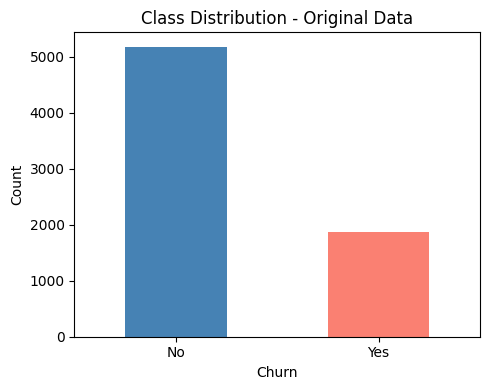

No Churn: 5174 (73.5%)
Churn:    1869 (26.5%)

Dataset is imbalanced - this is why we will use SMOTE later.


In [3]:
plt.figure(figsize=(5, 4))
df_raw['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution - Original Data')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

counts = df_raw['Churn'].value_counts()
print(f'No Churn: {counts["No"]} ({round(counts["No"]/len(df_raw)*100, 1)}%)')
print(f'Churn:    {counts["Yes"]} ({round(counts["Yes"]/len(df_raw)*100, 1)}%)')
print('\nDataset is imbalanced - this is why we will use SMOTE later.')

## Step 3 – Helper Function for Metrics

In [4]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4)
    }



---
# PART A – Without Preprocessing (Baseline)
We run all 4 models on raw data first to see how they perform without any preprocessing.
  
  We still encode text columns because models cannot read strings at all — but NO scaling and NO SMOTE.

## Step 4 – Prepare Baseline Data (No Scaling, No SMOTE)

In [5]:
df_base = df_raw.copy()


df_base['TotalCharges'] = pd.to_numeric(df_base['TotalCharges'], errors='coerce')
df_base['TotalCharges'].fillna(df_base['TotalCharges'].median(), inplace=True)

# drop customerID - not a feature
df_base.drop('customerID', axis=1, inplace=True)

# encode target column
df_base['Churn'] = df_base['Churn'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
for col in df_base.columns:
    if df_base[col].dtype == 'object':
        df_base[col] = le.fit_transform(df_base[col])

X_base = df_base.drop('Churn', axis=1)
y_base = df_base['Churn']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

print('Baseline data ready (no scaling, no SMOTE)')
print(f'Train: {X_train_b.shape[0]} rows, Test: {X_test_b.shape[0]} rows')

Baseline data ready (no scaling, no SMOTE)
Train: 5634 rows, Test: 1409 rows


## Step 5 – All 4 Models Without Preprocessing

In [6]:
# Model 1 - Decision Tree
dt_b = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_b.fit(X_train_b, y_train_b)
y_pred_dt_b = dt_b.predict(X_test_b)
print('Decision Tree (baseline) done.')

Decision Tree (baseline) done.


In [7]:
# Model 2 - Rule-Based Classifier
# rules based on contract type, tenure, and online security
X_test_b_df = pd.DataFrame(X_test_b, columns=X_base.columns)

def rule_based_raw(row):
    if row['Contract'] == 0 and row['tenure'] <= 12:
        return 1   
    elif row['Contract'] == 0 and row['OnlineSecurity'] == 0:
        return 1   
    elif row['Contract'] >= 1:
        return 0   
    elif row['tenure'] > 36:
        return 0   
    else:
        return 0

y_pred_rb_b = X_test_b_df.apply(rule_based_raw, axis=1).values
print('Rule-Based (baseline) done.')

Rule-Based (baseline) done.


In [8]:
# Model 3 - SVM
print('Running SVM.')
svm_b = SVC(kernel='linear', random_state=42)
svm_b.fit(X_train_b, y_train_b)
y_pred_svm_b = svm_b.predict(X_test_b)
print('SVM (baseline) done.')

Running SVM.
SVM (baseline) done.


In [9]:
# Model 4 - Logistic Regression
lr_b = LogisticRegression(max_iter=1000, random_state=42)
lr_b.fit(X_train_b, y_train_b)
y_pred_lr_b = lr_b.predict(X_test_b)
print('Logistic Regression (baseline) done.')

Logistic Regression (baseline) done.


In [10]:
# Baseline Results Table
baseline_results = pd.DataFrame([
    get_metrics(y_test_b, y_pred_dt_b,  'Decision Tree'),
    get_metrics(y_test_b, y_pred_rb_b,  'Rule-Based'),
    get_metrics(y_test_b, y_pred_svm_b, 'SVM'),
    get_metrics(y_test_b, y_pred_lr_b,  'Logistic Regression'),
]).set_index('Model')

print('    WITHOUT PREPROCESSING    ')
display(baseline_results)

    WITHOUT PREPROCESSING    


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7942,0.6056,0.6381,0.6214
Rule-Based,0.7048,0.4682,0.8499,0.6038
SVM,0.7935,0.6602,0.4531,0.5374
Logistic Regression,0.8169,0.6803,0.5818,0.6272


---
# PART B – With Full Preprocessing
Now we apply encoding + scaling + SMOTE and run all 4 models again.

## Step 6 – Full Preprocessing Pipeline

In [11]:
df = df_raw.copy()

# fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# drop customerID
df.drop('customerID', axis=1, inplace=True)

# encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# encode
le2 = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le2.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

# scale featuresfor SVM and Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Encoding and scaling done.')

Encoding and scaling done.


Before SMOTE - No Churn: 5174, Churn: 1869
After SMOTE  - No Churn: 5174, Churn: 5174


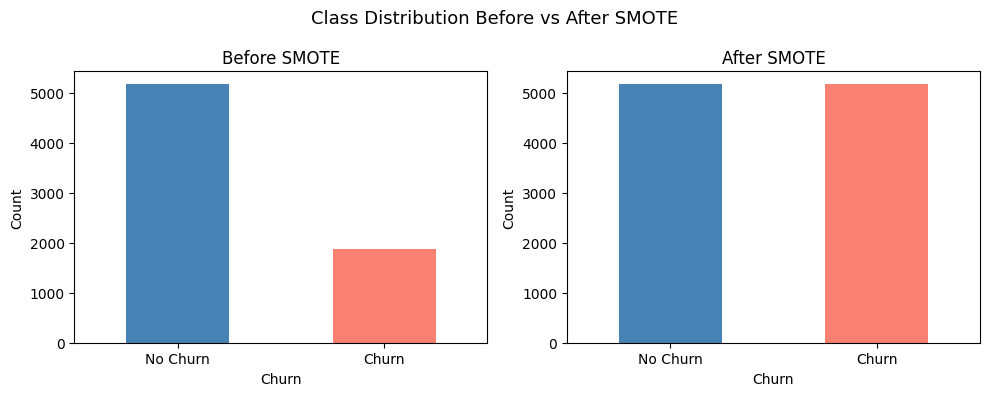

In [12]:
# apply SMOTE to balance classes
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print(f'Before SMOTE - No Churn: {sum(y==0)}, Churn: {sum(y==1)}')
print(f'After SMOTE  - No Churn: {sum(y_res==0)}, Churn: {sum(y_res==1)}')

# plot before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y).value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[0].set_ylabel('Count')

pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

print(f'Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows')

Train: 8278 rows, Test: 2070 rows


## Step 7 – All 4 Models With Preprocessing

In [14]:
# Model 1 - Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# overfitting check
train_acc = dt.score(X_train, y_train)
test_acc  = dt.score(X_test, y_test)
print(f'Decision Tree - Train Accuracy: {round(train_acc, 4)}')
print(f'Decision Tree - Test  Accuracy: {round(test_acc, 4)}')


Decision Tree - Train Accuracy: 0.7945
Decision Tree - Test  Accuracy: 0.7961


In [15]:
# Model 2 - Rule-Based Classifier (on scaled data)
# on scaled data, 0 = average value, negative = below average, positive = above average

def rule_based_scaled(row):
    if row['Contract'] < -0.8 and row['tenure'] < -0.5:
        return 1   
    elif row['Contract'] < -0.8 and row['OnlineSecurity'] < 0:
        return 1  
    elif row['Contract'] < -0.8 and row['MonthlyCharges'] > 0.5:
        return 1   
    elif row['Contract'] > 0.5 and row['tenure'] > 0:
        return 0   
    elif row['tenure'] > 1.0:
        return 0   
    else:
        return 0

y_pred_rb = X_test_df.apply(rule_based_scaled, axis=1).values
print('Rule-Based done.')

Rule-Based done.


In [16]:
# Model 3 - SVM

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print('SVM done.')

SVM done.


In [17]:
# Model 4 - Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

churn_probs = lr.predict_proba(X_test)[:, 1]
print('Sample churn probabilities for first 5 customers:')
print([round(p, 3) for p in churn_probs[:5]])


Sample churn probabilities for first 5 customers:
[np.float64(0.651), np.float64(0.259), np.float64(0.403), np.float64(0.696), np.float64(0.441)]


In [18]:
# With Preprocessing Results Table
processed_results = pd.DataFrame([
    get_metrics(y_test, y_pred_dt,  'Decision Tree'),
    get_metrics(y_test, y_pred_rb,  'Rule-Based'),
    get_metrics(y_test, y_pred_svm, 'SVM'),
    get_metrics(y_test, y_pred_lr,  'Logistic Regression'),
]).set_index('Model')

print(' WITH PREPROCESSING ')
display(processed_results)

 WITH PREPROCESSING 


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7961,0.7710,0.8503,0.8087
Rule-Based,0.7401,0.6976,0.8599,0.7703
SVM,0.7899,0.7619,0.8513,0.8041
Logistic Regression,0.7937,0.7743,0.8370,0.8044


---
# PART C – Visualizations

## Step 8 – Feature Importance (Decision Tree)

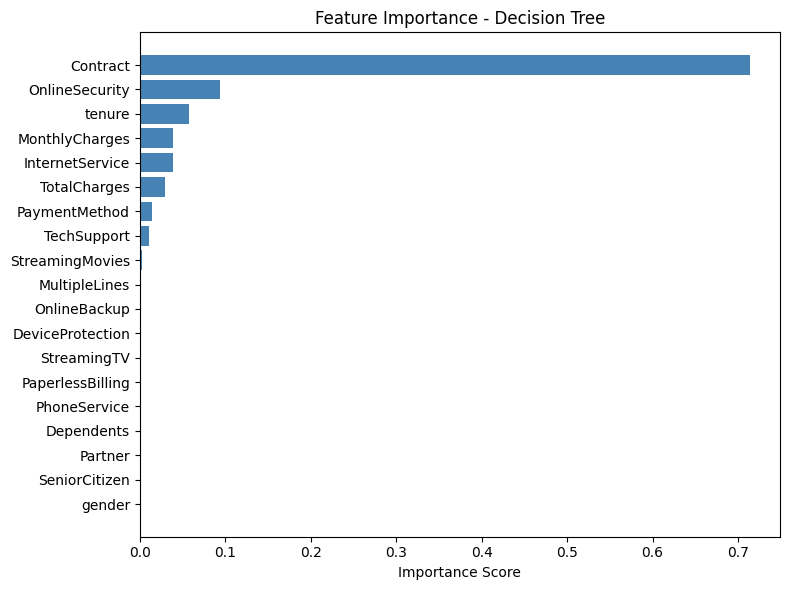

Top 5 features influencing churn:
            Feature  Importance
14         Contract    0.713420
8    OnlineSecurity    0.093794
4            tenure    0.057859
17   MonthlyCharges    0.039259
7   InternetService    0.039061


In [19]:
feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance')

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features influencing churn:')
print(feat_df.tail(5)[['Feature', 'Importance']].iloc[::-1].to_string())

## Step 9 – All 4 Confusion Matrices

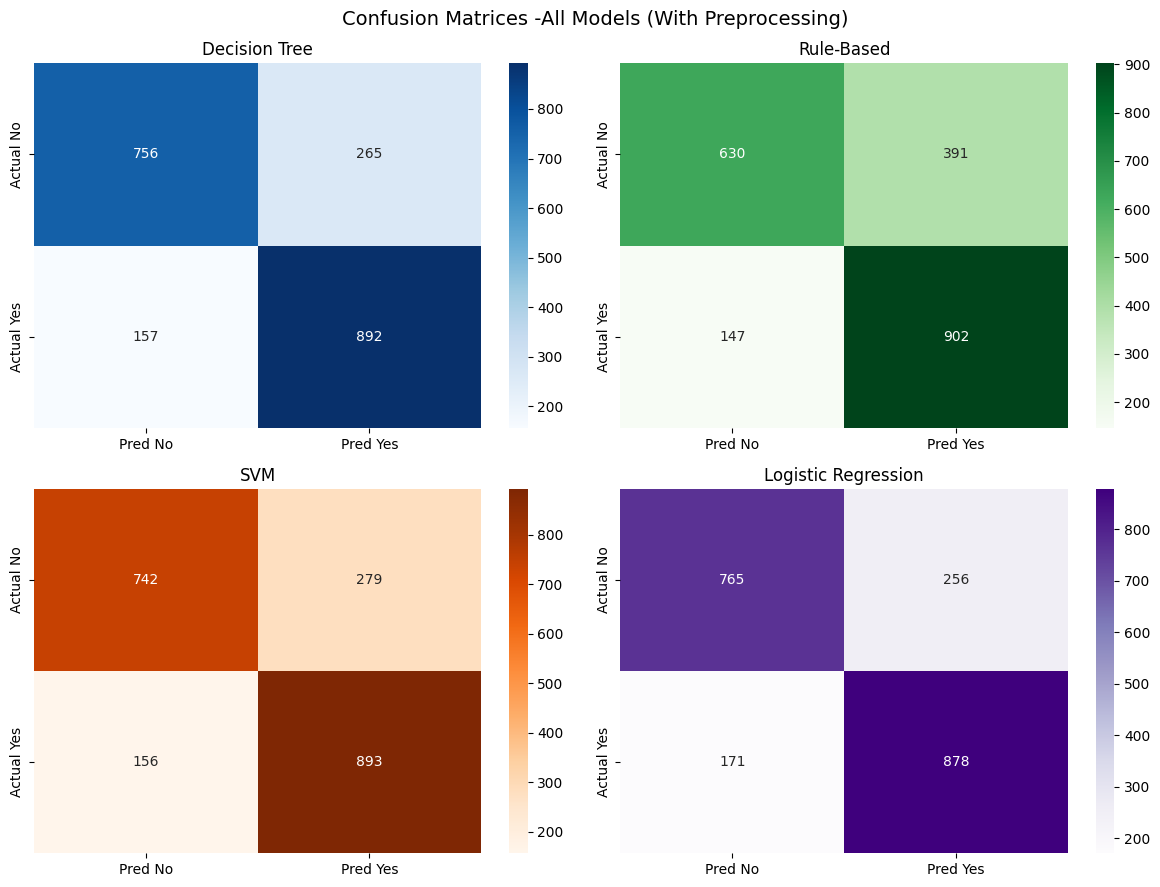

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

models_info = [
    (y_pred_dt,  'Decision Tree',       'Blues'),
    (y_pred_rb,  'Rule-Based',          'Greens'),
    (y_pred_svm, 'SVM',                 'Oranges'),
    (y_pred_lr,  'Logistic Regression', 'Purples'),
]

for ax, (preds, name, cmap) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Actual No', 'Actual Yes'])
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices -All Models (With Preprocessing)', fontsize=14)
plt.tight_layout()
plt.show()

## Step 10 – Before vs After Preprocessing Comparison

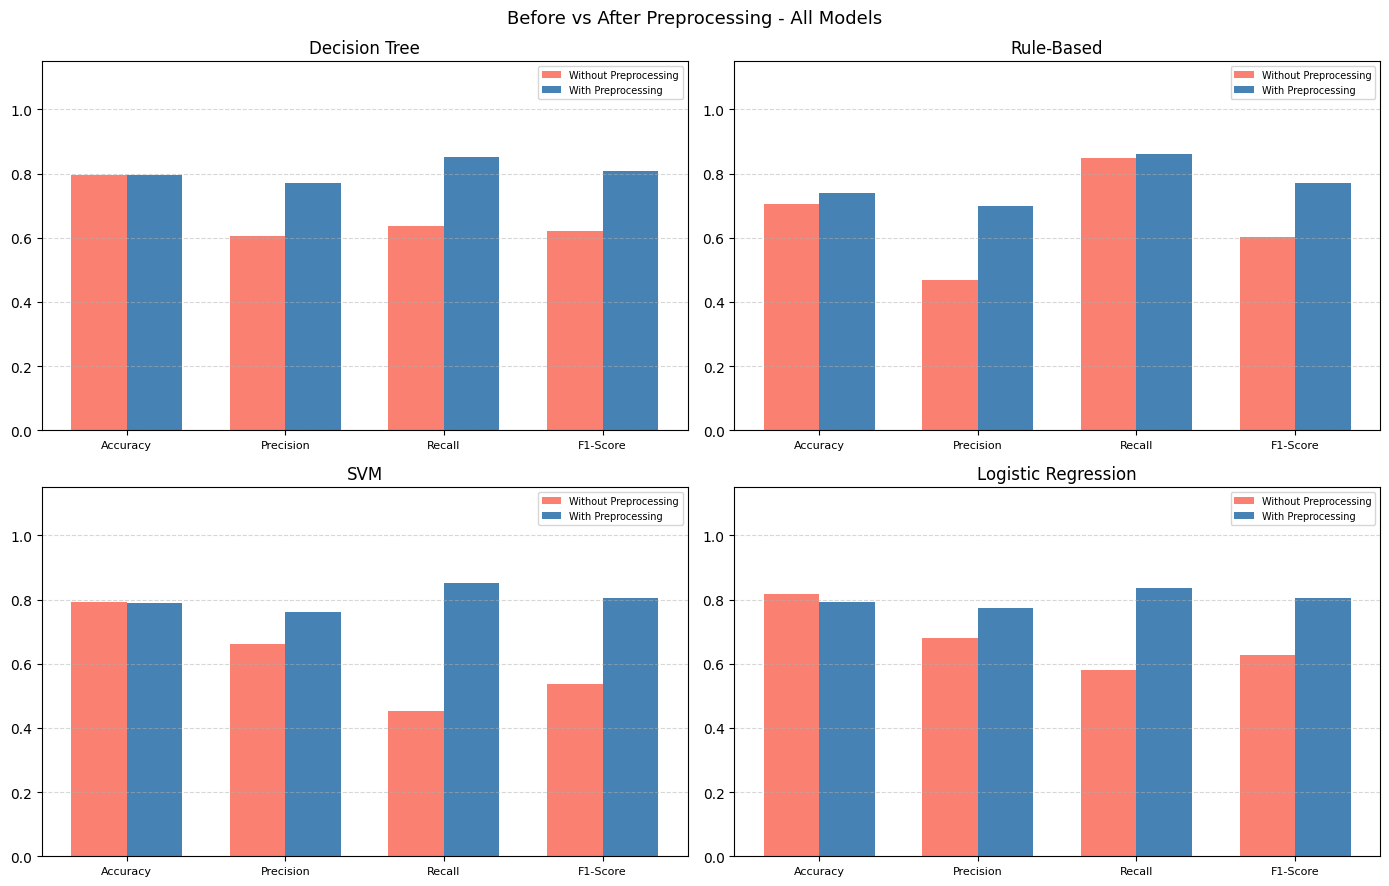

In [21]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = ['Decision Tree', 'Rule-Based', 'SVM', 'Logistic Regression']
x = np.arange(len(metric_cols))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, name in zip(axes.flatten(), model_names):
    before = [baseline_results.loc[name, m] for m in metric_cols]
    after  = [processed_results.loc[name, m] for m in metric_cols]
    ax.bar(x - width/2, before, width, label='Without Preprocessing', color='salmon')
    ax.bar(x + width/2, after,  width, label='With Preprocessing',    color='steelblue')
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols, fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Before vs After Preprocessing - All Models', fontsize=13)
plt.tight_layout()
plt.show()

## Step 11 – Final Model Comparison Chart

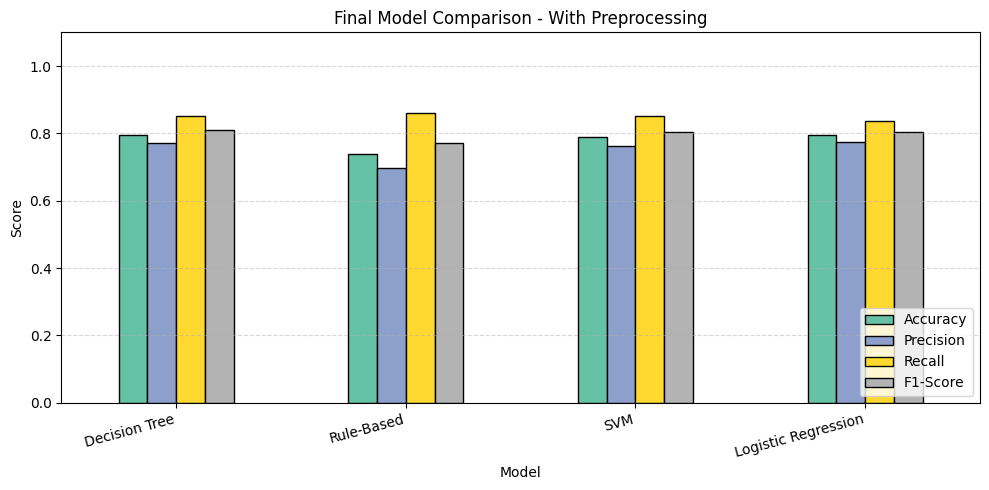

In [22]:
processed_results.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Final Model Comparison - With Preprocessing')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
# PART D – Analysis & Conclusion

## Step 12 – Preprocessing Impact Table

In [23]:
print('WITHOUT PREPROCESSING:')
display(baseline_results)

print('\nWITH PREPROCESSING:')
display(processed_results)

print('\nIMPACT OF PREPROCESSING (positive = improved):')
impact = processed_results - baseline_results
display(impact.round(4))

WITHOUT PREPROCESSING:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7942,0.6056,0.6381,0.6214
Rule-Based,0.7048,0.4682,0.8499,0.6038
SVM,0.7935,0.6602,0.4531,0.5374
Logistic Regression,0.8169,0.6803,0.5818,0.6272



WITH PREPROCESSING:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7961,0.7710,0.8503,0.8087
Rule-Based,0.7401,0.6976,0.8599,0.7703
SVM,0.7899,0.7619,0.8513,0.8041
Logistic Regression,0.7937,0.7743,0.8370,0.8044



IMPACT OF PREPROCESSING (positive = improved):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.0019,0.1654,0.2122,0.1873
Rule-Based,0.0353,0.2294,0.0100,0.1665
SVM,-0.0036,0.1017,0.3982,0.2667
Logistic Regression,-0.0232,0.0940,0.2552,0.1772


## Step 13 – Final Results & Best Model


In [24]:
best_recall = processed_results['Recall'].idxmax()
best_f1     = processed_results['F1-Score'].idxmax()

print('=== FINAL RESULTS (With Preprocessing) ===')
display(processed_results)

print(f'\nBest Model by Recall:   {best_recall}')
print(f'Best Model by F1-Score: {best_f1}')



=== FINAL RESULTS (With Preprocessing) ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7961,0.7710,0.8503,0.8087
Rule-Based,0.7401,0.6976,0.8599,0.7703
SVM,0.7899,0.7619,0.8513,0.8041
Logistic Regression,0.7937,0.7743,0.8370,0.8044



Best Model by Recall:   Rule-Based
Best Model by F1-Score: Decision Tree
